<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/14_Polynomial_rideg_lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
!gdown 1nBNY8uePbDqcLQlKXyLFlnOMTKpB3mSS

Downloading...
From: https://drive.google.com/uc?id=1nBNY8uePbDqcLQlKXyLFlnOMTKpB3mSS
To: /content/insurance.csv
100% 54.3k/54.3k [00:00<00:00, 64.3MB/s]


In [ ]:
insurance = pd.read_csv("insurance.csv").drop_duplicates()
data = pd.get_dummies(insurance, drop_first=True, dtype=int)

In [ ]:
data.shape

(1337, 9)

In [ ]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [ ]:
X = data.drop(columns="charges")
y = data["charges"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(1069, 8)

In [ ]:
def score(model, X_train, X_test):
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train) # coef_ , intercept_
    # print(model.coef_)
    # print(model.intercept_)

    y_pred = model.predict(X_test)

    print("train R2:", round(model.score(X_train, y_train), 3),
          "| test R2:", round(r2_score(y_test, y_pred), 3),
          "| MAE:", round(mean_absolute_error(y_test, y_pred)))

model = LinearRegression()
score(model, X_train, X_test)      # 8 features

train R2: 0.73 | test R2: 0.807 | MAE: 4177


In [ ]:
from sklearn.pipeline import make_pipeline

In [ ]:
# One feature, non-smokers only, and just 30 training customers
non_smokers = insurance[insurance["smoker"] == "no"]

train_small, test_small = train_test_split(non_smokers, test_size=0.2, random_state=42)

train_small = train_small.sample(30, random_state=1)


for degree in [1, 2, 3,4,5,10,15,20]:
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    model.fit(train_small[["age"]], train_small["charges"])

    y_pred = model.predict(test_small[["age"]])

    train_r2 = model.score(train_small[["age"]], train_small["charges"])
    test_r2 = r2_score(test_small["charges"],  y_pred)

    print(f"degree {degree:2d} | train R2 {train_r2:.3f} | test R2 {test_r2:.3f}")

degree  1 | train R2 0.433 | test R2 0.341
degree  2 | train R2 0.465 | test R2 0.367
degree  3 | train R2 0.467 | test R2 0.368
degree  4 | train R2 0.516 | test R2 0.207
degree  5 | train R2 0.621 | test R2 -0.038
degree 10 | train R2 0.726 | test R2 -130.650
degree 15 | train R2 0.775 | test R2 -97121615.408
degree 20 | train R2 0.779 | test R2 -7280136936.911


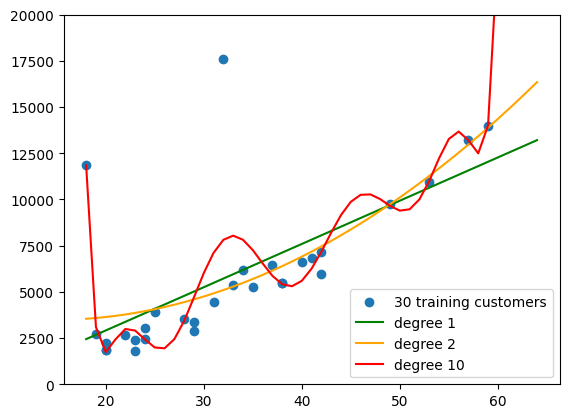

In [ ]:
ages = pd.DataFrame({"age": range(18, 65)})

plt.scatter(train_small["age"], train_small["charges"], label="30 training customers")
for degree, colour in [(1, "green"), (2, "orange"), (10, "red")]:
    model = make_pipeline(PolynomialFeatures(degree), StandardScaler(), LinearRegression())
    model.fit(train_small[["age"]], train_small["charges"])
    plt.plot(ages, model.predict(ages), color=colour, label=f"degree {degree}")
plt.ylim(0, 20000)
plt.legend()
plt.show()

## Polynomial Features

In [ ]:
X_train.shape

(1069, 8)

In [ ]:
poly2 = PolynomialFeatures(degree=2)
poly2.fit(X_train)
X_train_poly2 = poly2.transform(X_train)
X_test_poly2 = poly2.transform(X_test)

scaler2 = StandardScaler()
scaler2.fit(X_train_poly2)
X_train_poly2 = scaler2.transform(X_train_poly2)
X_test_poly2 = scaler2.transform(X_test_poly2)

print(X_train.shape)
print(X_train_poly2.shape)

(1069, 8)
(1069, 45)


In [ ]:
X_train_poly2[0]

array([ 0.        , -1.1576804 , -0.99692768, -0.90790804,  0.97140947,
       -0.50029231, -0.57266946, -0.60581158, -0.57410974, -1.07164925,
       -1.23832046, -0.84335756,  0.13905873, -0.46280522, -0.52913386,
       -0.55744551, -0.5326633 , -0.95879348, -0.88528153,  0.54109563,
       -0.48788264, -0.56161947, -0.59014559, -0.56152068, -0.60782839,
       -0.54969014, -0.32876654, -0.37184941, -0.36695278, -0.34649854,
        0.97140947, -0.36881636, -0.38660363, -0.40086768, -0.37370958,
       -0.50029231, -0.20472013, -0.26873156, -0.21205138, -0.57266946,
        0.        ,  0.        , -0.60581158,  0.        , -0.57410974])

In [ ]:
# Squares and every pairwise product.
list(poly2.get_feature_names_out(X.columns)[:20])

['1',
 'age',
 'bmi',
 'children',
 'sex_male',
 'smoker_yes',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age^2',
 'age bmi',
 'age children',
 'age sex_male',
 'age smoker_yes',
 'age region_northwest',
 'age region_southeast',
 'age region_southwest',
 'bmi^2',
 'bmi children',
 'bmi sex_male']

## Performance

In [ ]:
for d in range(1, 10):
    poly3 = PolynomialFeatures(degree=d)
    scaler3 = StandardScaler()

    poly3.fit(X_train)
    X_train_poly = poly3.transform(X_train)
    X_test_poly = poly3.transform(X_test)

    scaler3.fit(X_train_poly)
    X_train_scaled = scaler3.transform(X_train_poly)
    X_test_scaled = scaler3.transform(X_test_poly)


    print("degree", d, "| features:", X_train_scaled.shape[1], "| training rows:", X_train_scaled.shape[0])
    score(LinearRegression(), X_train_scaled, X_test_scaled)
    print()

degree 1 | features: 9 | training rows: 1069
train R2: 0.73 | test R2: 0.807 | MAE: 4177

degree 2 | features: 45 | training rows: 1069
train R2: 0.834 | test R2: 0.883 | MAE: 2867

degree 3 | features: 165 | training rows: 1069
train R2: 0.847 | test R2: 0.871 | MAE: 3049

degree 4 | features: 495 | training rows: 1069
train R2: 0.867 | test R2: 0.8 | MAE: 3756

degree 5 | features: 1287 | training rows: 1069
train R2: 0.903 | test R2: -2.004 | MAE: 7990

degree 6 | features: 3003 | training rows: 1069
train R2: 0.939 | test R2: -215538.86 | MAE: 1472976

degree 7 | features: 6435 | training rows: 1069
train R2: 0.965 | test R2: -10336.691 | MAE: 427713

degree 8 | features: 12870 | training rows: 1069
train R2: 0.987 | test R2: -201903363.929 | MAE: 39846436

degree 9 | features: 24310 | training rows: 1069
train R2: 0.996 | test R2: -1502196532.404 | MAE: 89773234



In [ ]:
plain = LinearRegression().fit(X_train_scaled, y_train)
print("largest coefficient:", f"{np.abs(plain.coef_).max():,.0f}")

largest coefficient: 25,064


## Regularisation

In [ ]:
for alpha in [0, 1, 10, 100, 1000, 1e4, 1e5, 1e6 ]:

    model = Ridge(alpha=alpha) # L2 regularisation
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, y_pred)
    train_r2 = model.score(X_train_scaled, y_train)

    print(f"alpha {alpha:<5} | train R2 {train_r2:.3f} test R2 {test_r2:.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


alpha 0     | train R2 0.981 test R2 -1241215.677
alpha 1     | train R2 0.898 test R2 0.274
alpha 10    | train R2 0.882 test R2 0.787
alpha 100   | train R2 0.865 test R2 0.830
alpha 1000  | train R2 0.847 test R2 0.833
alpha 10000.0 | train R2 0.804 test R2 0.825
alpha 100000.0 | train R2 0.685 test R2 0.726
alpha 1000000.0 | train R2 0.449 test R2 0.447


In [ ]:
for alpha in [0, 1, 10, 100, 1000, 1e4, 1e5, 1e6 ]:

    model = Lasso(alpha=alpha) # L1 regularisation
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    test_r2 = r2_score(y_test, y_pred)
    train_r2 = model.score(X_train_scaled, y_train)

    print(f"alpha {alpha:<5} | train R2 {train_r2:.3f} test R2 {test_r2:.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.683e+09, tolerance: 1.464e+07 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

alpha 0     | train R2 0.895 test R2 0.073


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.553e+09, tolerance: 1.464e+07
  model = cd_fast.enet_coordinate_descent(


alpha 1     | train R2 0.888 test R2 0.536


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.387e+08, tolerance: 1.464e+07
  model = cd_fast.enet_coordinate_descent(


alpha 10    | train R2 0.861 test R2 0.847
alpha 100   | train R2 0.838 test R2 0.873
alpha 1000  | train R2 0.802 test R2 0.860
alpha 10000.0 | train R2 0.000 test R2 -0.008
alpha 100000.0 | train R2 0.000 test R2 -0.008
alpha 1000000.0 | train R2 0.000 test R2 -0.008


In [ ]:
lasso = Lasso(alpha=100, max_iter=100000).fit(X_train_scaled, y_train)
kept = pd.Series(lasso.coef_, index=poly3.get_feature_names_out(X.columns))

kept[kept != 0].sort_values(key=abs, ascending=False).head(6).round()

,0
bmi^2 smoker_yes,8123.0
age^2,2614.0
bmi^2 smoker_yes^2,1537.0
bmi^7 smoker_yes region_southeast,-627.0
bmi children,593.0
bmi^2 smoker_yes^7,514.0


In [ ]:
lasso.coef_.shape

(24310,)

In [ ]:
np.sum(lasso.coef_==0) # useless features; weights = 0

np.int64(24174)